In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
    
sys.path.insert(1, os.path.dirname(os.path.dirname(os.getcwd())))
import precision_mapping as pm

# Loads test suite paths
from precision_mapping.tests.constants_test_suite import *

In [63]:
dtseries_path = TEST_DTSERIES_PATH  # path to dtseries or .txt with lines of dtseries paths
subject_id = TEST_SUBJECT_ID  # name of subject (output directory will use this)
sample_label = TEST_SAMPLE_LABEL # sample label (normally '{subject}_additional_info')
outdir = TEST_DIR_PATH # output directory
censor_file = TEST_DTSERIES_CENSOR_FILE # path to frame censoring .dat file

# pm.precision_mapping(dtseries_path, subject_id, sample_label, outdir,
#                      censor_files=censor_file, device="default", seed=4,
#                      sparsity=0.01, n_infomaps_reps=1, overwrite=True)

In [69]:

# dtseries_path = '/System/Volumes/Data/data/data7/HCP_7T/100610/MNINonLinear/Results/rfMRI_REST_7T_ALL/rfMRI_REST_7T_ALL_Atlas_hp2000_clean_nilearn.dtseries.nii'
# censor_file = None
npz_path = "/data/data7/network_control/projects/pfm_analysis/results/HCP_analysis/100610/100610_rfMRI_REST_7T_ALL_vertex_FC.npz"

# Rewriting core sparse_correlator :(

In [70]:
import scipy
import numpy as np
import torch
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

In [71]:
mask = scipy.sparse.load_npz(pm.constants.DEFAULT_MASK)

sparsity = 0.1
voxel_data = pm.cifti_tools.load_voxel_data(dtseries_path, censor_file=censor_file)
exclude_index = np.arange(voxel_data.shape[1]) >= 59_412

block_size=1000
leave=False
SC_kwargs = {}

backend = np
backend = torch

In [76]:
zmat = pm.sparse_correlator.top_row_correlations(voxel_data, sparsity=0.1, window_size=100, mask=mask,
                                                 backend="torch", device="mps", exclude_index=exclude_index, leave=False)
# scipy.sparse.save_npz(npz_path, zmat)

Top K Sparse Correlation:   0%|          | 0/913 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [30]:
scipy.sparse.save_npz(npz_path, zmat)

In [498]:
12574273 / 91282

137.75194452356433

In [474]:
scipy.sparse.save_npz(npz_path, zmat)

In [482]:
hmat = scipy.sparse.load_npz(npz_path)

In [480]:
zmat

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 83340466 stored elements and shape (91282, 91282)>

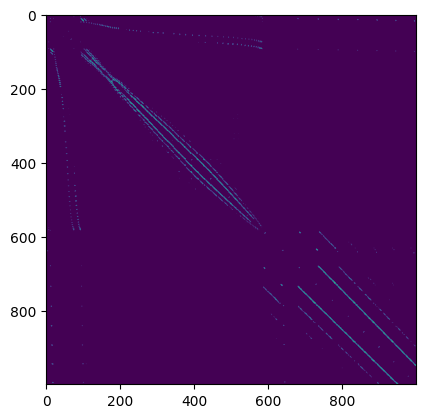

In [28]:
plt.imshow(zmat[:1000, :1000].todense())

In [270]:
x = pm.spc_utils.to_backend(backend, voxel_data)
y = pm.spc_utils.to_backend(backend, voxel_data)

x, y = x.T, y.T
x_demeaned = x - x.mean(axis=1, keepdims=True)
y_demeaned = y - y.mean(axis=1, keepdims=True)

x_norm = x_demeaned / backend.sqrt(backend.sum(x_demeaned ** 2, axis=1, keepdims=True))
y_norm = y_demeaned / backend.sqrt(backend.sum(y_demeaned ** 2, axis=1, keepdims=True))

n_vertices = y_norm.shape[0]
k_top_vertices = int(np.ceil(sparsity * y_norm.shape[0]))
k_top_vertices

913

In [429]:
window_size = 100

n_windows = int(np.ceil(y_norm.shape[0] / window_size))
c_x_indices, c_values = [], []
for i in tqdm(range(n_windows)):
    window_start_index = i * window_size
    window_end_index = window_start_index + window_size
    y_window_slice = slice(window_start_index, window_start_index + window_size)
    y_window = y_norm[y_window_slice]

    corr_window = (x_norm @ y_window.T)
    # excludes diagonal
    corr_window[np.arange(window_start_index, window_end_index), np.arange(window_size)] = 0
    # excludes exclude_index
    corr_window[exclude_index] = 0

    # excludes mask
    mask_window = ~pm.spc_utils.sparse_to_array(mask[:, y_window_slice].astype(bool))
    mask_window = pm.spc_utils.to_backend(backend, mask_window, dtype=bool, **device_info)
    corr_window = corr_window * mask_window
    
    cw_values, cw_x_indices = pm.spc_utils.MPS_safe_topk(backend, device_info, corr_window, k_top_vertices, axis=0)
    c_x_indices.append(cw_x_indices)
    c_values.append(cw_values)
    
    if i > -1:
        break

c_values = backend.concat(c_values, axis=1)
c_x_indices = backend.concat(c_x_indices, axis=1)
c_y_indices = backend.arange(n_vertices).tile(k_top_vertices, 1)

  0%|          | 0/913 [00:00<?, ?it/s]

In [430]:
mask_window = ~pm.spc_utils.sparse_to_array(mask[:, y_window_slice].astype(bool))
mask_window = pm.spc_utils.to_backend(backend, mask_window, dtype=bool, **device_info)

In [431]:
mask_window.shape

torch.Size([91282, 100])

In [432]:
corr_window[np.arange(window_start_index, window_end_index), np.arange(window_size)] = 0

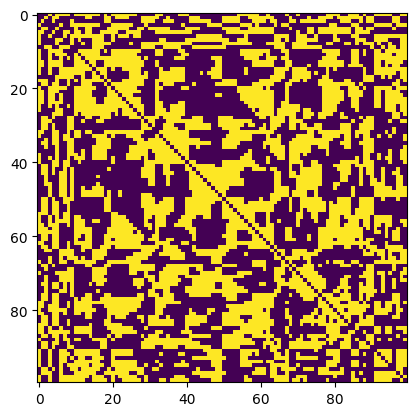

In [433]:
plt.imshow(corr_window[y_window_slice, :window_size] > 0)

In [365]:
z = corr_window * mask_window

In [366]:
torch.sum(z[:, 0] > 0)

tensor(45908)

In [275]:
corr_window[exclude_index] = 0

In [276]:
corr_window

tensor([[ 1.4445e-01,  5.1904e-01,  6.8831e-01,  ..., -3.6970e-01,
          1.1788e-01,  2.3520e-01],
        [-6.9083e-01,  4.6165e-01,  2.7206e-01,  ..., -1.2637e-01,
         -3.9806e-01,  5.3681e-01],
        [-4.8422e-01, -2.0935e-01, -5.3943e-01,  ...,  3.8183e-01,
         -4.8683e-01,  3.2666e-05],
        ...,
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
          0.0000e+00,  0.0000e+00]])

In [220]:
c_x_indices = c_x_indices.ravel()
c_y_indices = c_y_indices.ravel()
c_values = c_values.ravel()

In [221]:
tv, ri, ci = pm.spc_utils.to_np((c_values, c_x_indices, c_y_indices))

In [222]:
zmat = scipy.sparse.csr_matrix((tv, (ri.astype(int), ci.astype(int))), shape=(n_vertices, n_vertices))

In [224]:
scipy.sparse.save_npz(npz_path, sc)

In [208]:
pm.spc_utils.get_nnz_safe(zmat)

83340466

In [85]:
x_norm.shape, y_norm.shape, yns.shape

(torch.Size([91282, 29]), torch.Size([91282, 29]), torch.Size([3, 29]))

In [101]:
z = (x_norm @ yns.T)
print(z.shape)

torch.Size([91282, 3])


In [102]:
device_info = pm.spc_utils.get_device_info(backend, "cpu")

In [103]:
k_top_vertices = int(np.ceil(sparsity * voxel_data.shape[1]))

In [106]:
pm.spc_utils.MPS_safe_topk(backend, device_info, z, k_top_vertices, axis=0)[0].shape

torch.Size([913, 3])

In [107]:
z[np.argsort(z[:, 0])[-k_top_vertices:], 0]

tensor([0.8260, 0.8260, 0.8260, 0.8260, 0.8260, 0.8261, 0.8261, 0.8262, 0.8262,
        0.8262, 0.8263, 0.8263, 0.8266, 0.8266, 0.8267, 0.8267, 0.8268, 0.8268,
        0.8268, 0.8269, 0.8271, 0.8273, 0.8273, 0.8273, 0.8273, 0.8274, 0.8274,
        0.8275, 0.8275, 0.8275, 0.8276, 0.8276, 0.8276, 0.8276, 0.8276, 0.8276,
        0.8277, 0.8277, 0.8277, 0.8278, 0.8279, 0.8280, 0.8280, 0.8281, 0.8282,
        0.8282, 0.8282, 0.8285, 0.8286, 0.8286, 0.8286, 0.8287, 0.8287, 0.8288,
        0.8289, 0.8289, 0.8289, 0.8290, 0.8291, 0.8291, 0.8293, 0.8293, 0.8294,
        0.8295, 0.8296, 0.8297, 0.8298, 0.8298, 0.8298, 0.8299, 0.8299, 0.8299,
        0.8300, 0.8301, 0.8301, 0.8301, 0.8301, 0.8302, 0.8302, 0.8303, 0.8303,
        0.8303, 0.8304, 0.8305, 0.8305, 0.8307, 0.8307, 0.8307, 0.8309, 0.8309,
        0.8310, 0.8312, 0.8313, 0.8313, 0.8313, 0.8313, 0.8314, 0.8314, 0.8314,
        0.8315, 0.8315, 0.8316, 0.8316, 0.8316, 0.8317, 0.8318, 0.8319, 0.8319,
        0.8320, 0.8320, 0.8320, 0.8320, 

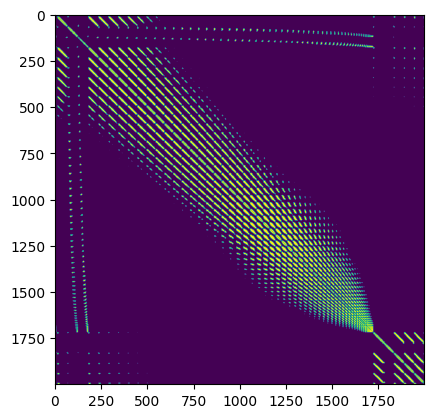

In [333]:
plt.imshow(pm.spc_utils.sparse_to_array(mask[:2000, :2000]))

In [21]:

sc = pm.sparse_correlator.SparseCorrelator.run(voxel_data, sparsity_percent=sparsity, symmetric=True,
                          mask=mask, exclude_index=exclude_index,
                          block_size=block_size, leave=leave, **SC_kwargs)

SparseCorrelator Block Analysis:   0%|          | 0/4278.0 [00:00<?, ?it/s]

In [3]:
from precision_mapping import functional_connectivity as fc

In [4]:
fc.generate_correlation_matrix(TEST_DTSERIES_PATH, TEST_OUTPUT_VERTEX_FC_PATH,
                               censor_file=TEST_DTSERIES_CENSOR_FILE,
                               sparsity=0.01,
                               exclude_index_path=None,
                               mask=30,
                                block_size=2_000,
                                overwrite=True, leave=True)

SparseCorrelator Block Analysis:   0%|          | 0/4324.0 [00:00<?, ?it/s]

'/System/Volumes/Data/data/data7/network_control/projects/precision_mapping/tests/outputs/example_vertex_FC.npz'